<a href="https://colab.research.google.com/github/mfernandezzz/Data-Analysis-Projects/blob/main/medical_data_visualizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Medical Data Visualizer**

In this project, you will visualize and make calculations from medical examination data using matplotlib, seaborn and pandas. The dataset values were collected during medical examinations.

Data description
The rows in the dataset represent patients and the columns represent information like body measurements, results from various blood tests, and lifestyle choices. You will use the dataset to explore the relationship cardiac disease, body measurements, blood markers, and lifestyle choices.

Instructions
Create a chart where we show the counts of good and bad outcomes for the cholesterol, gluc, alco, active, and smoke variables for patients with cardio=0 and cardio=1 in different panels.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('/content/medical_examination.csv')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


**Add an overweight column to the data. To determine if a person is overweight, first calculate their BMI (Body Mass Index) by dividing their weight in kilograms by the square of their height in meters. If that value is >25, then the person is overweight. Use the value 0 for not overweight and the value 1 for overweight.**



In [3]:
#create a new column called overweight and assign the BMI based in the columns weight and height
#if the BMI is > 25, the value will be True, otherwise will be False
df['overweight'] = (df['weight'] / ((df['height'] / 100) ** 2) > 25)
#assign value 0 to False and value 1 to True
df['overweight'] = df['overweight'].astype(int)
#df['overweight'] = df['overweight'].replace({True = 1, False: 0})
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,0
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,0


**Normalize data by making 0 always good and 1 always bad. If the value of cholesterol or gluc is 1, set the value to 0. If the value is more than 1, set the value to 1.**

In [4]:
df.head(10)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,0
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,0
5,8,21914,1,151,67.0,120,80,2,2,0,0,0,0,1
6,9,22113,1,157,93.0,130,80,3,1,0,0,1,0,1
7,12,22584,2,178,95.0,130,90,3,3,0,0,1,1,1
8,13,17668,1,158,71.0,110,70,1,1,0,0,1,0,1
9,14,19834,1,164,68.0,110,60,1,1,0,0,0,0,1


In [5]:
#if the values in the columns cholesterol and gluc are greater than 1, assign 1 and assign 0 if not
#use of the .apply() method with a lambda function
df['cholesterol'] = df['cholesterol'].apply(lambda x: 1 if x > 1 else 0)
df['gluc'] = df['gluc'].apply(lambda x: 1 if x > 1 else 0)
df.head(10)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
0,0,18393,2,168,62.0,110,80,0,0,0,0,1,0,0
1,1,20228,1,156,85.0,140,90,1,0,0,0,1,1,1
2,2,18857,1,165,64.0,130,70,1,0,0,0,0,1,0
3,3,17623,2,169,82.0,150,100,0,0,0,0,1,1,1
4,4,17474,1,156,56.0,100,60,0,0,0,0,0,0,0
5,8,21914,1,151,67.0,120,80,1,1,0,0,0,0,1
6,9,22113,1,157,93.0,130,80,1,0,0,0,1,0,1
7,12,22584,2,178,95.0,130,90,1,1,0,0,1,1,1
8,13,17668,1,158,71.0,110,70,0,0,0,0,1,0,1
9,14,19834,1,164,68.0,110,60,0,0,0,0,0,0,1


In [6]:
df.shape

(70000, 14)

**Draw a categorical plot in the draw_cat_plot function.
Create a DataFrame for the cat plot using pd.melt with values from cholesterol, gluc, smoke, alco, active and overweight in the df_cat variable. Group and reformat the data in df_cat to split by cardio. Show the count of each feature. You will have to rename one of the columns for the catplot to work correctly. Convert the data into long format and create a chart that shows the value counts of the categorical features using the following method provided by the seaborn library import: sns.catplot(). Get the figure for the output and store and store it in the fig variable.**

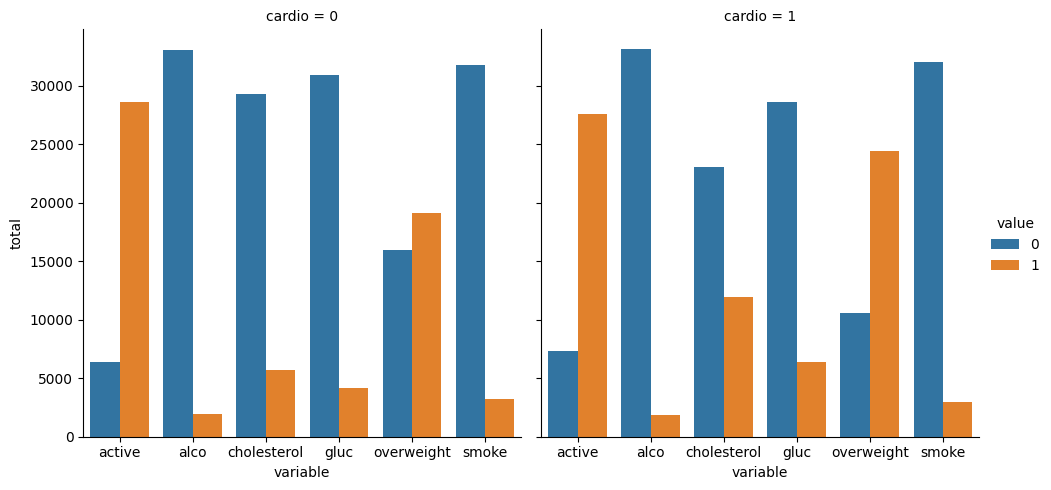

In [7]:
#function that creates a categorical plot
def draw_cat_plot():
  #df_cat variable and the .melt pandas to specify the values for the plot (value_vars)
  #previously, split by cardio the value_vars (id_vars variable)
  df_cat = pd.melt(df, id_vars='cardio', value_vars=['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'overweight'],
                   var_name='feature', value_name='value')

  #group the DataFrame by cardio and feature to get counts
  df_cat = df_cat.groupby(['cardio', 'feature', 'value']).size().reset_index(name='total')

  #rename the feature variable as required by seaborn
  df_cat.rename(columns={'feature': 'variable'}, inplace=True)

  #method sns.catplot() to create the chart on a new variable
  #in data specify the dataframe variable, specify the label for the x and y axis, the name of the columns and the type of plot
  catplot = sns.catplot(data=df_cat, x='variable', y='total', col='cardio', hue='value', kind='bar', height=5, aspect=1)

  #fig = catplot.fig
  #fig.savefig('catplot.png')
  return catplot

draw_cat_plot()

**Draw the heat map in the draw_heat_map function. Clean the data in the df_heat variable by filtering out the following patient segments that represents incorrect data: diastolic pressure is higher than systolic (Keep the correct data with (df['ap_lo'] <= df['ap_hi']))
height is less than the 2.5th percentile (Keep the correct data with (df['height'] >= df['height'].quantile(0.025)))
height is more than the 97.5th percentile
weight is less than the 2.5th percentile
weight is more than the 97.5th percentile
Calculate the correlation matrix and store it in the corr variable. Generate a mask for the upper triangle and store it in the mask variable. Set up the matplotlib figure. Plot the correlation matrix using the method provided by the seaborn library import: sns.heatmap()**

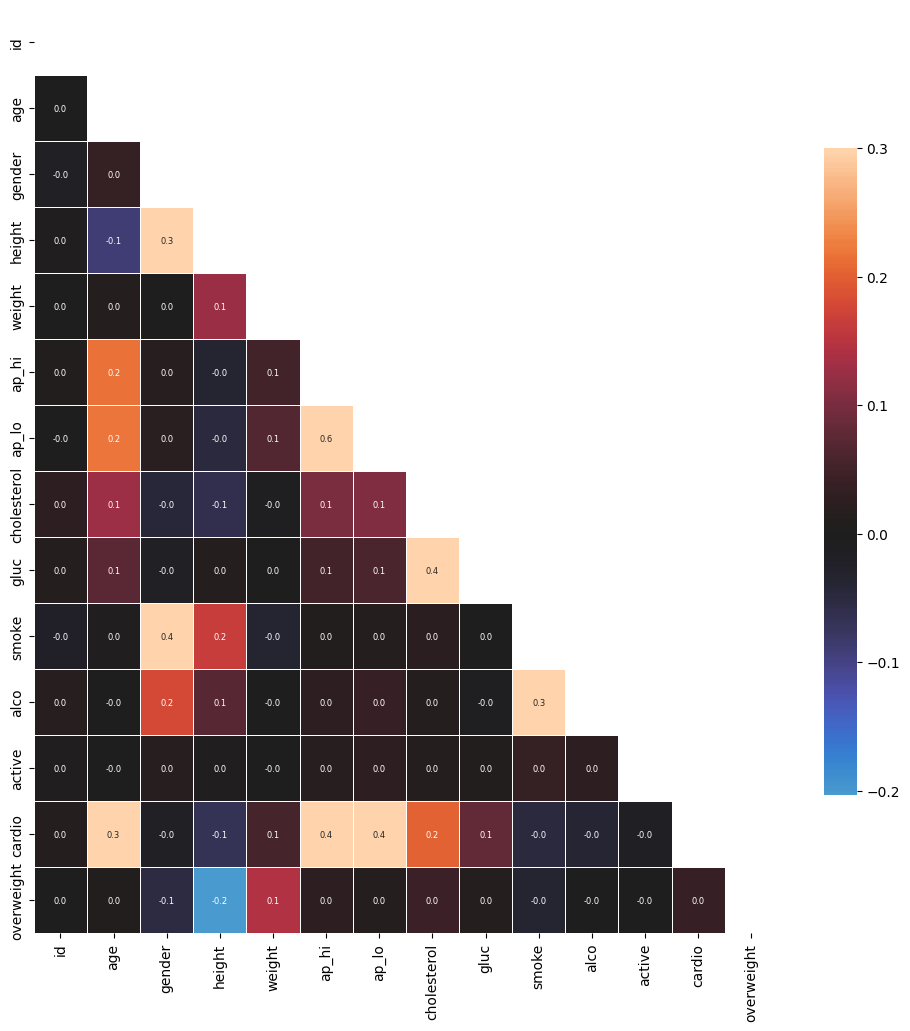

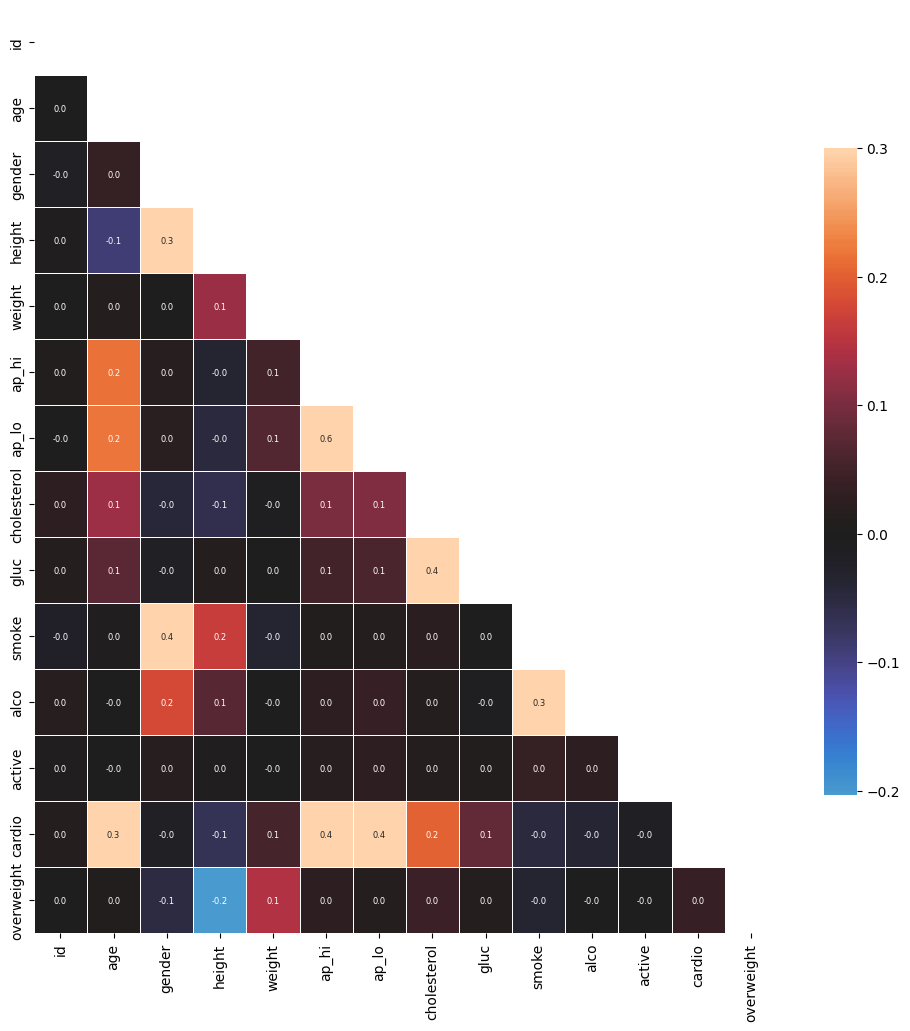

In [8]:
def draw_heat_map():
  #create a new DataFrame with the data cleaned
  #filter out the patients segments that represents incorrect data
  df_heat = df[
            (df['ap_lo'] <= df['ap_hi']) & #diatolic pressure higher than systolic
            (df['height'] >= df['height'].quantile(0.025)) & #height is less than the 2.5 percentile
            (df['height'] <= df['height'].quantile(0.975)) & #height is more than the 97.5 percentile
            (df['weight'] >= df['weight'].quantile(0.025)) & #weight is less than the 2.5 percentile
            (df['weight'] <= df['weight'].quantile(0.0975)) #weight is more than the 97.5 percentile
            ]
  #obtain the correlation matrix from the df_heat dataframe
  corr = df_heat.corr()
  #generate a mask for the upper triangle
  mask = np.triu(np.ones_like(df_heat.corr(), dtype=bool))

  #matplotlib figure
  fig, ax = plt.subplots(figsize=(12, 12))

  #plot the correlation matrix using the respective method provided by the seaborn library
  sns.heatmap(data=corr, annot=True, fmt=".1f", linewidth=.5, mask=mask, annot_kws={'fontsize':6}, cbar_kws={"shrink": .7}, square=False, center=0, vmax=0.30);

  #fig.savefig('heatmap.png')
  return fig

draw_heat_map()